In [ ]:
import numpy as np

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from scipy.optimize import curve_fit

import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

from functions.read_g4bl_data import readTraceData
from functions.set_plot_settings import setPlotSettings

setPlotSettings(font=True)

## With gas

In [19]:
file_gas = 'ReferenceParticle_gas.txt'
data_gas = readTraceData(file_gas)

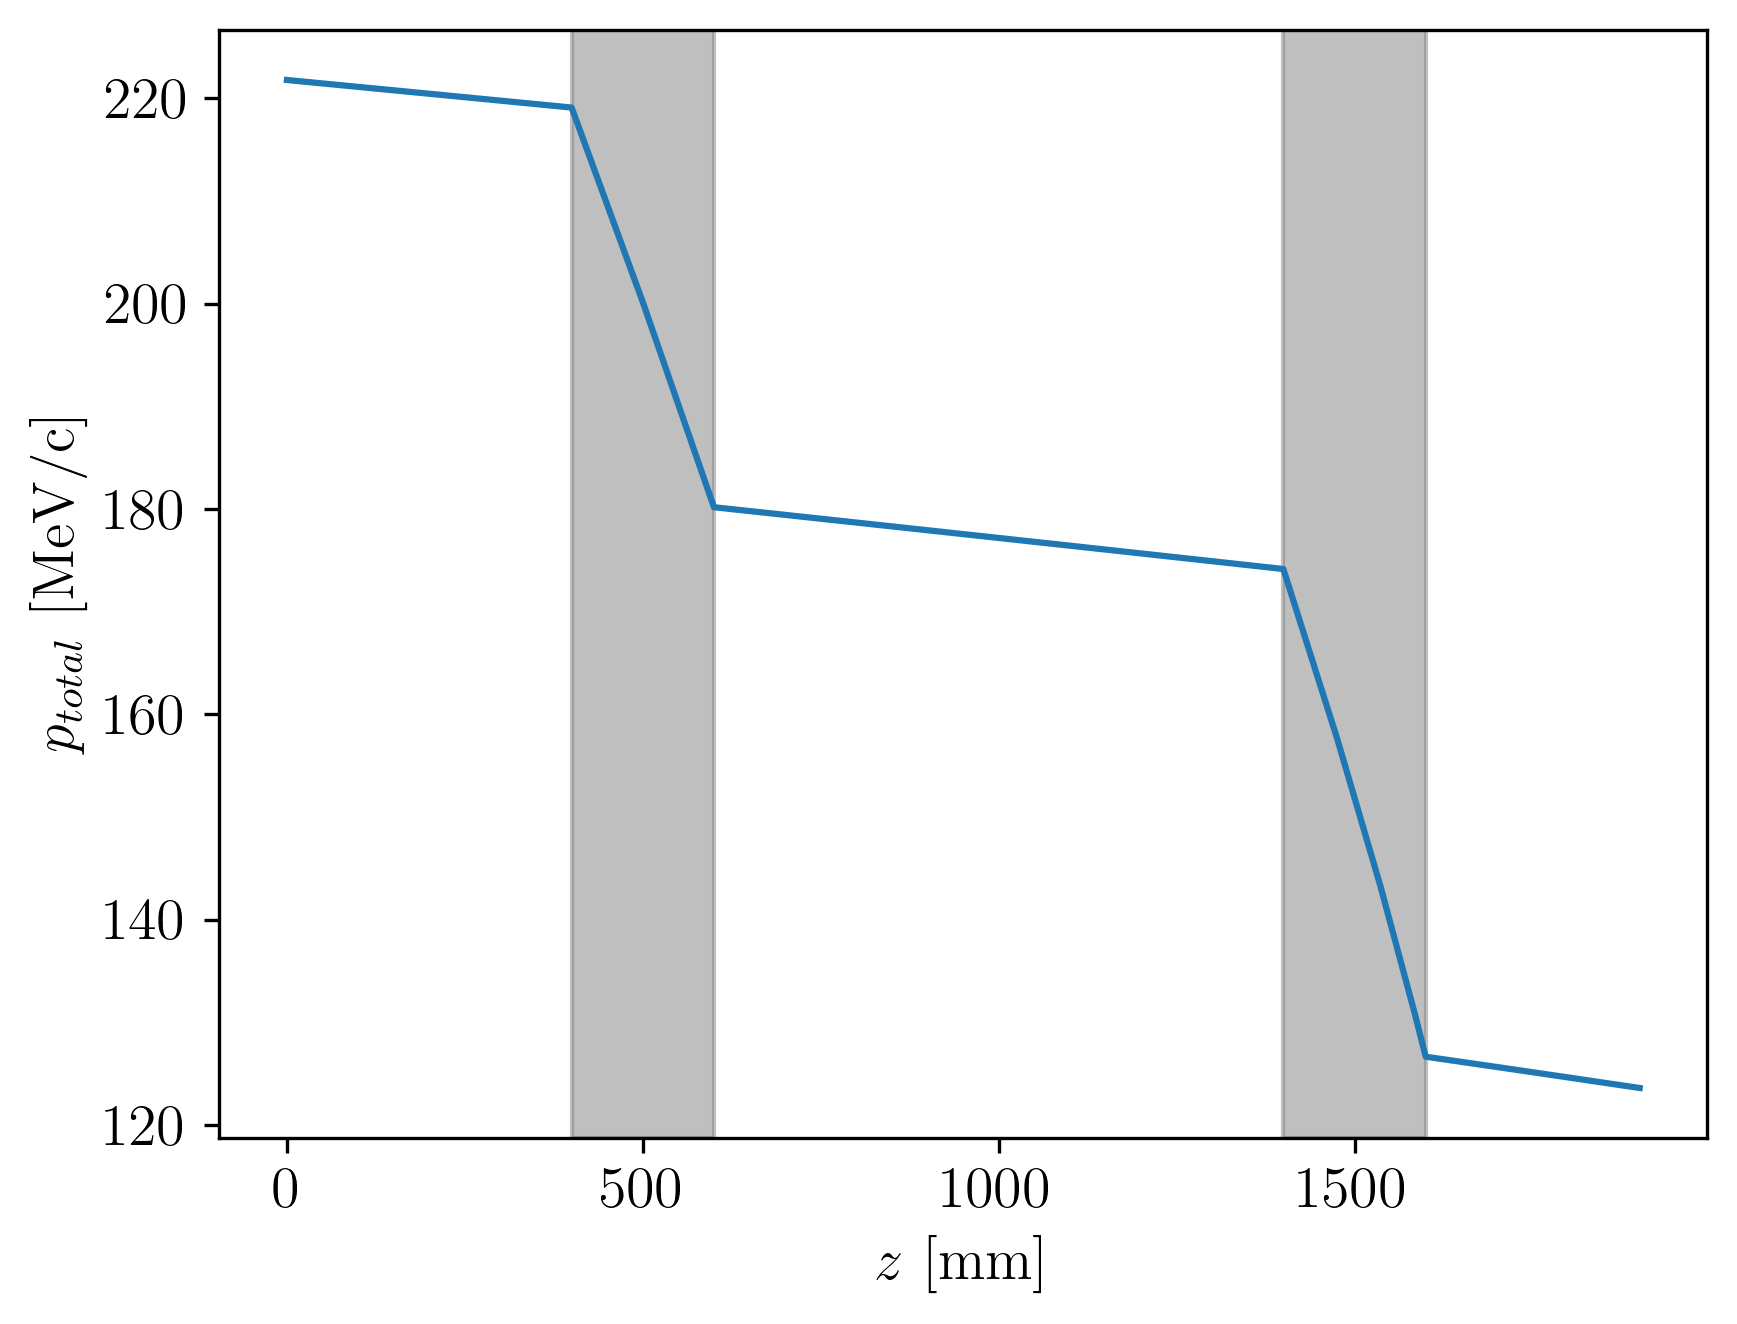

In [20]:
plt.plot(data_gas['z'], data_gas['ptotal'])
plt.axvspan(400,600,color='gray',alpha=0.5,zorder=-1)
plt.axvspan(1400,1600,color='gray',alpha=0.5,zorder=-1)
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]');

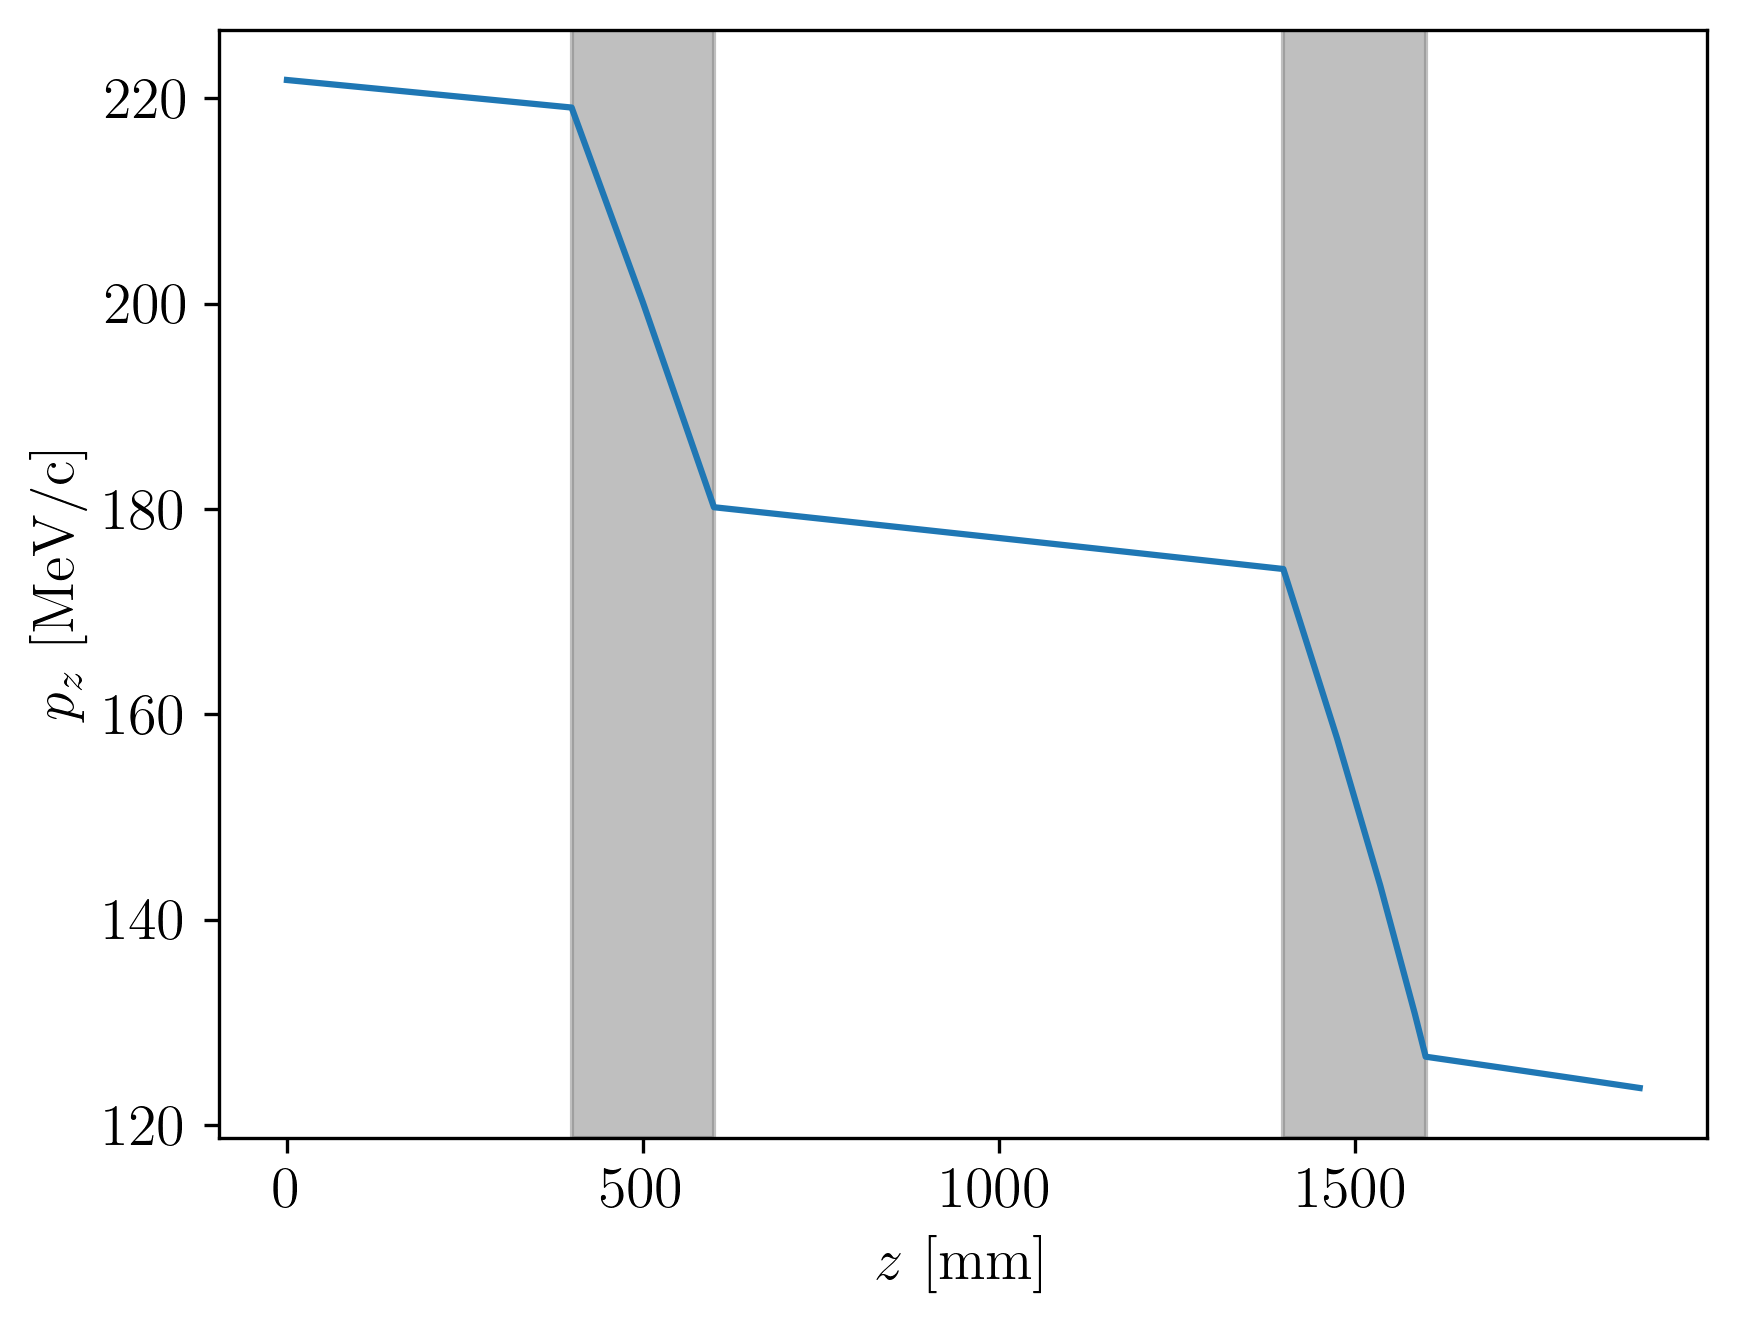

In [21]:
plt.plot(data_gas['z'], data_gas['pz'])
plt.axvspan(400,600,color='gray',alpha=0.5,zorder=-1)
plt.axvspan(1400,1600,color='gray',alpha=0.5,zorder=-1)
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{z}$ [MeV/c]');

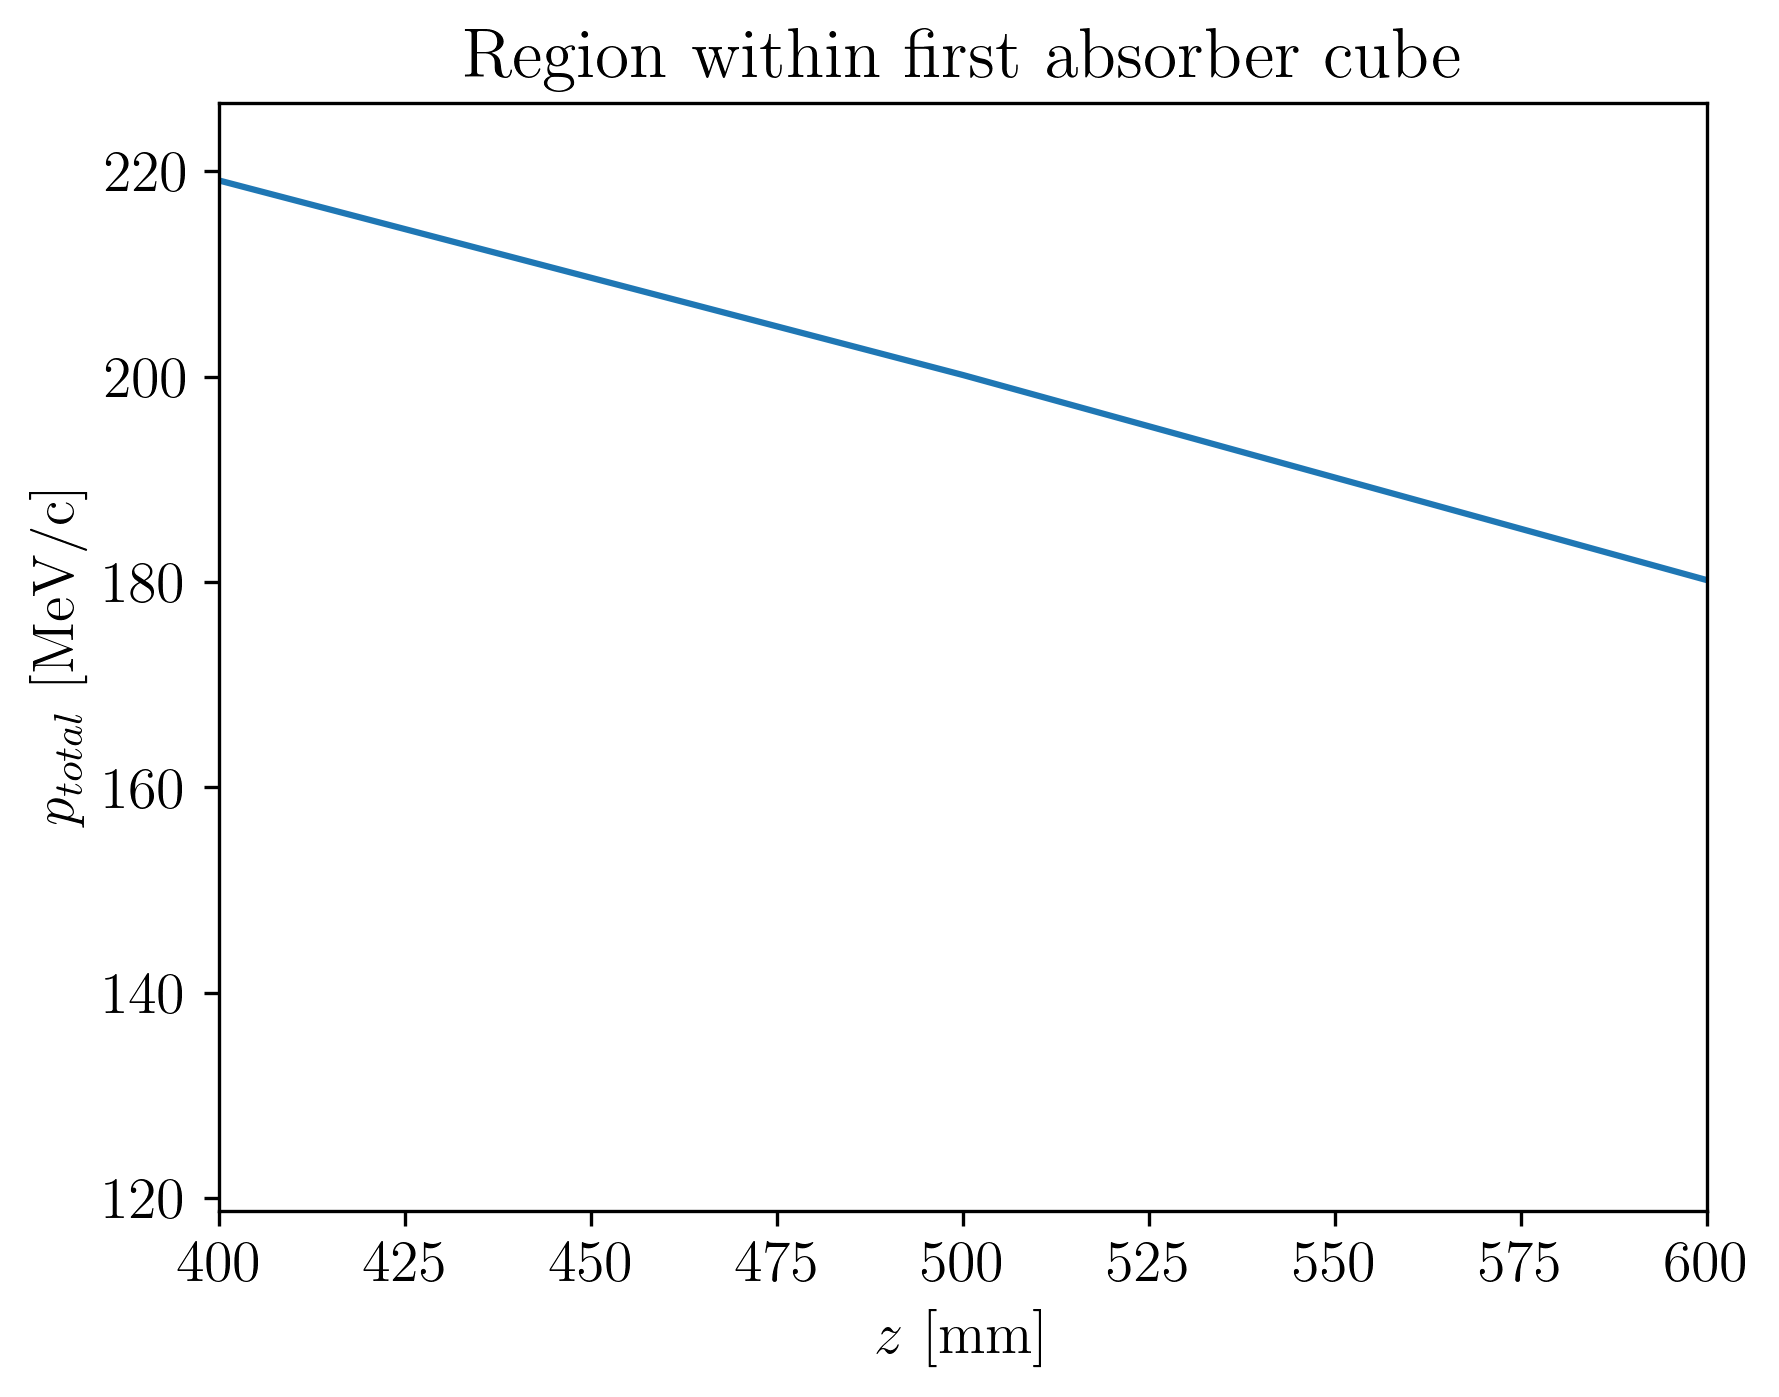

In [22]:
plt.plot(data_gas['z'], data_gas['ptotal'])
plt.xlim((400,600))
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]')
plt.title('Region within first absorber cube');

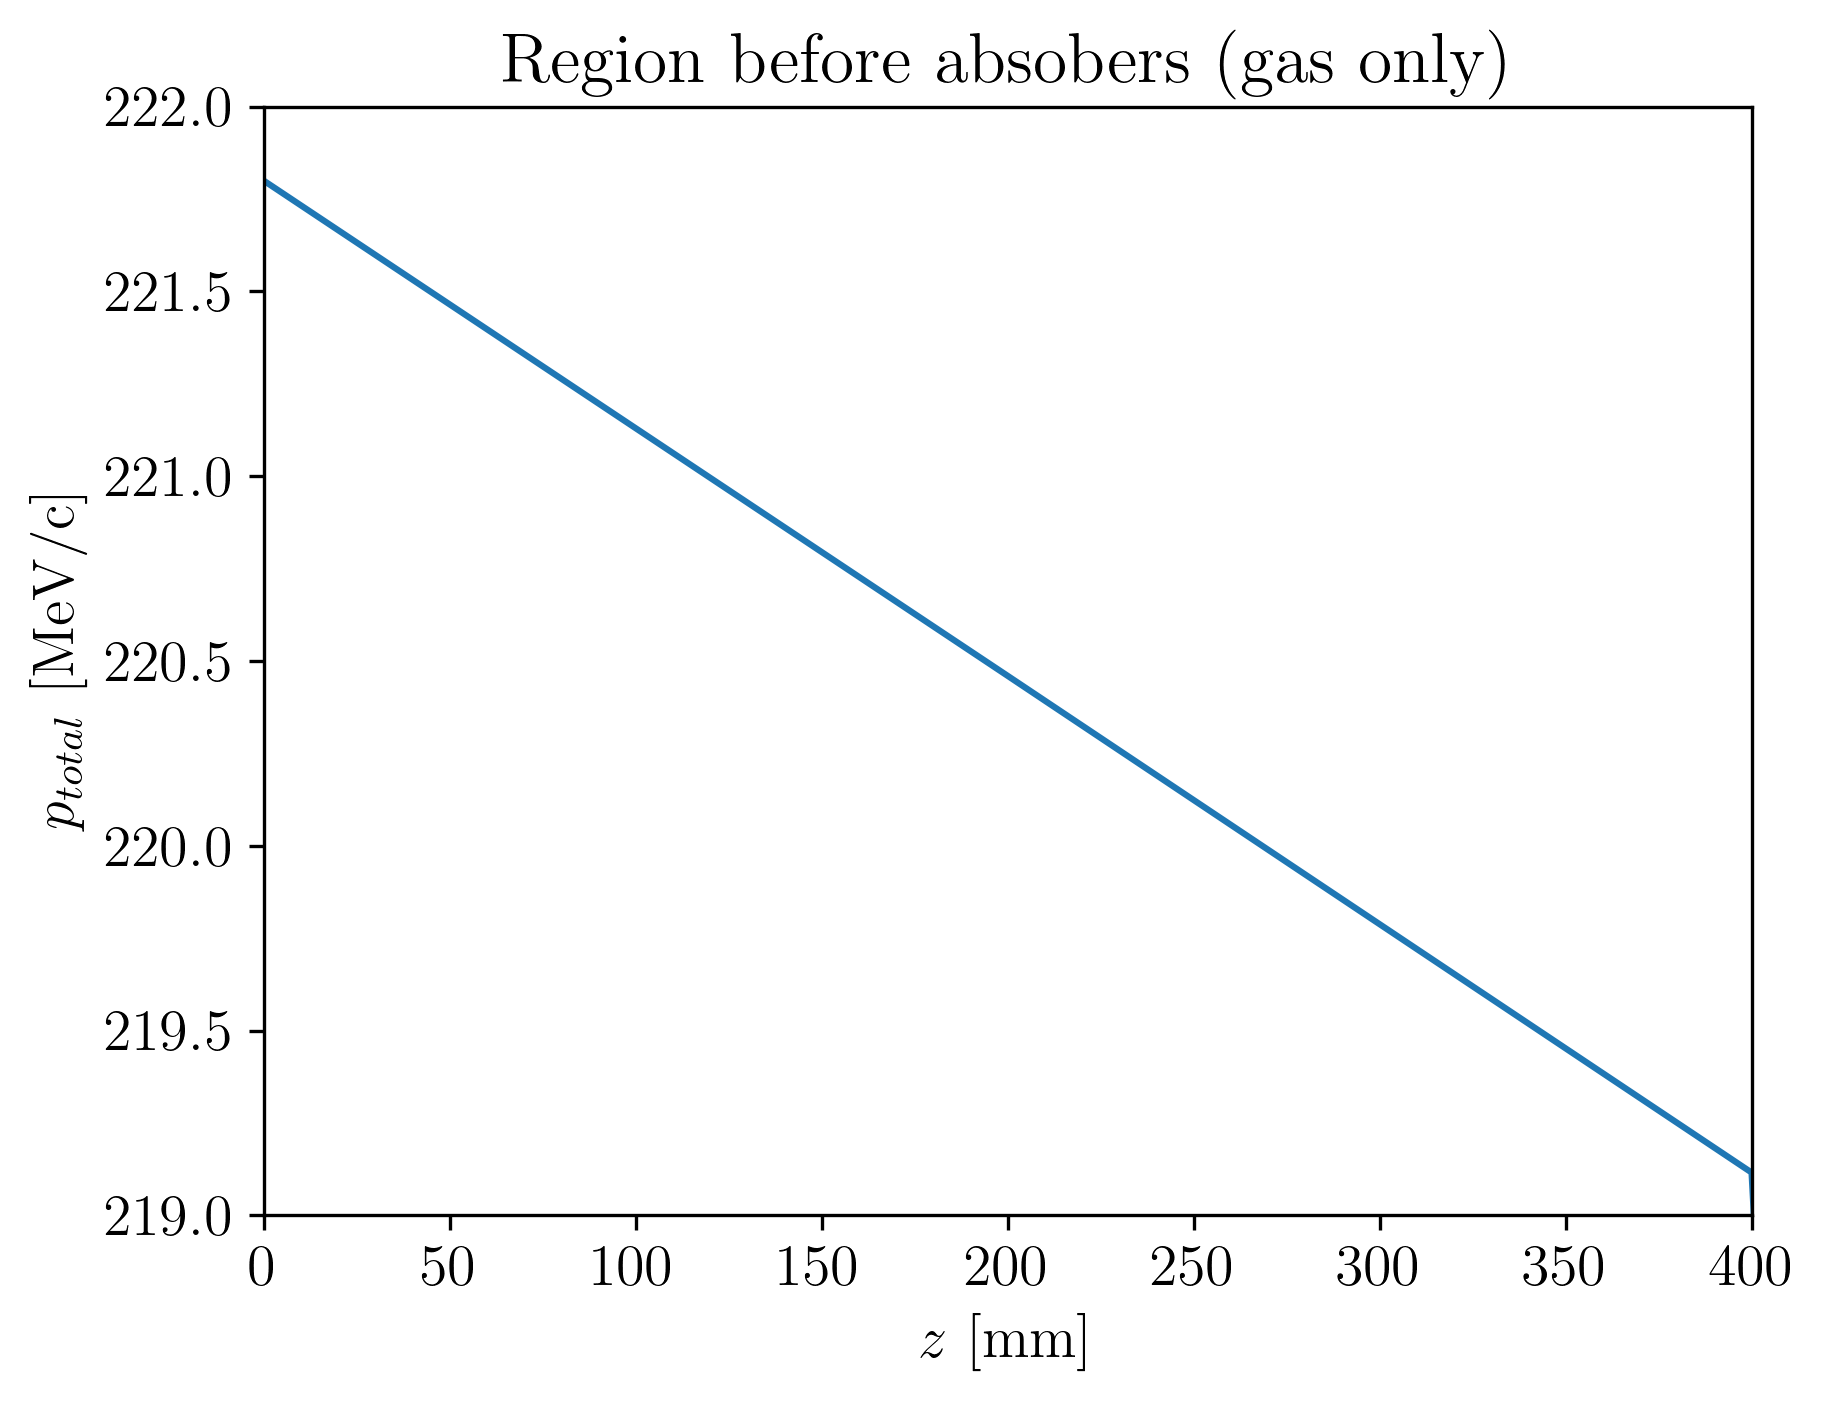

In [23]:
plt.plot(data_gas['z'], data_gas['ptotal'])
plt.xlim((0,400))
plt.ylim((219,222))
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]')
plt.title('Region before absobers (gas only)');

## Vacuum

In [24]:
file_vac = 'ReferenceParticle_vacuum.txt'
data_vac = readTraceData(file_vac)

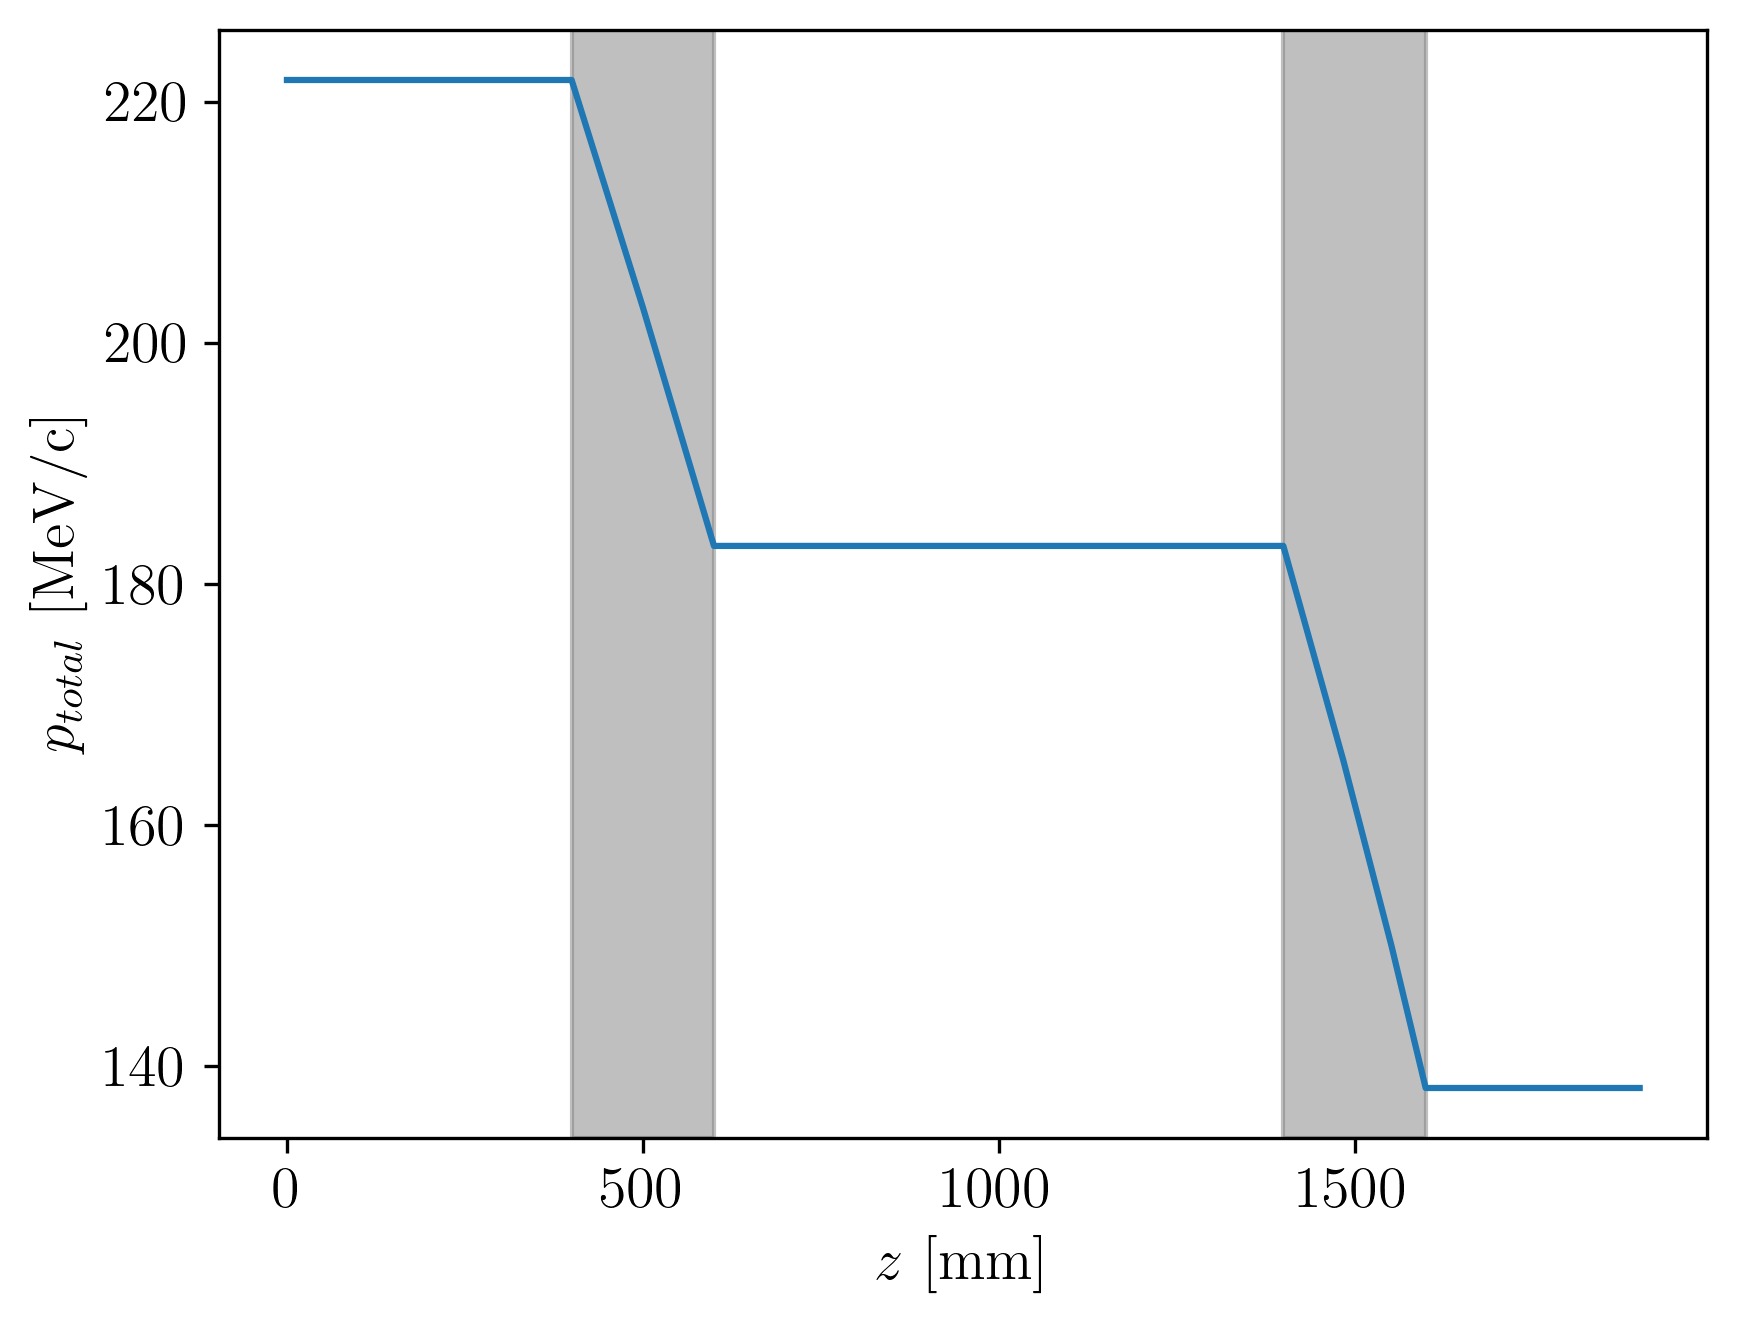

In [25]:
plt.plot(data_vac['z'], data_vac['ptotal'])
plt.axvspan(400,600,color='gray',alpha=0.5,zorder=-1)
plt.axvspan(1400,1600,color='gray',alpha=0.5,zorder=-1)
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]');

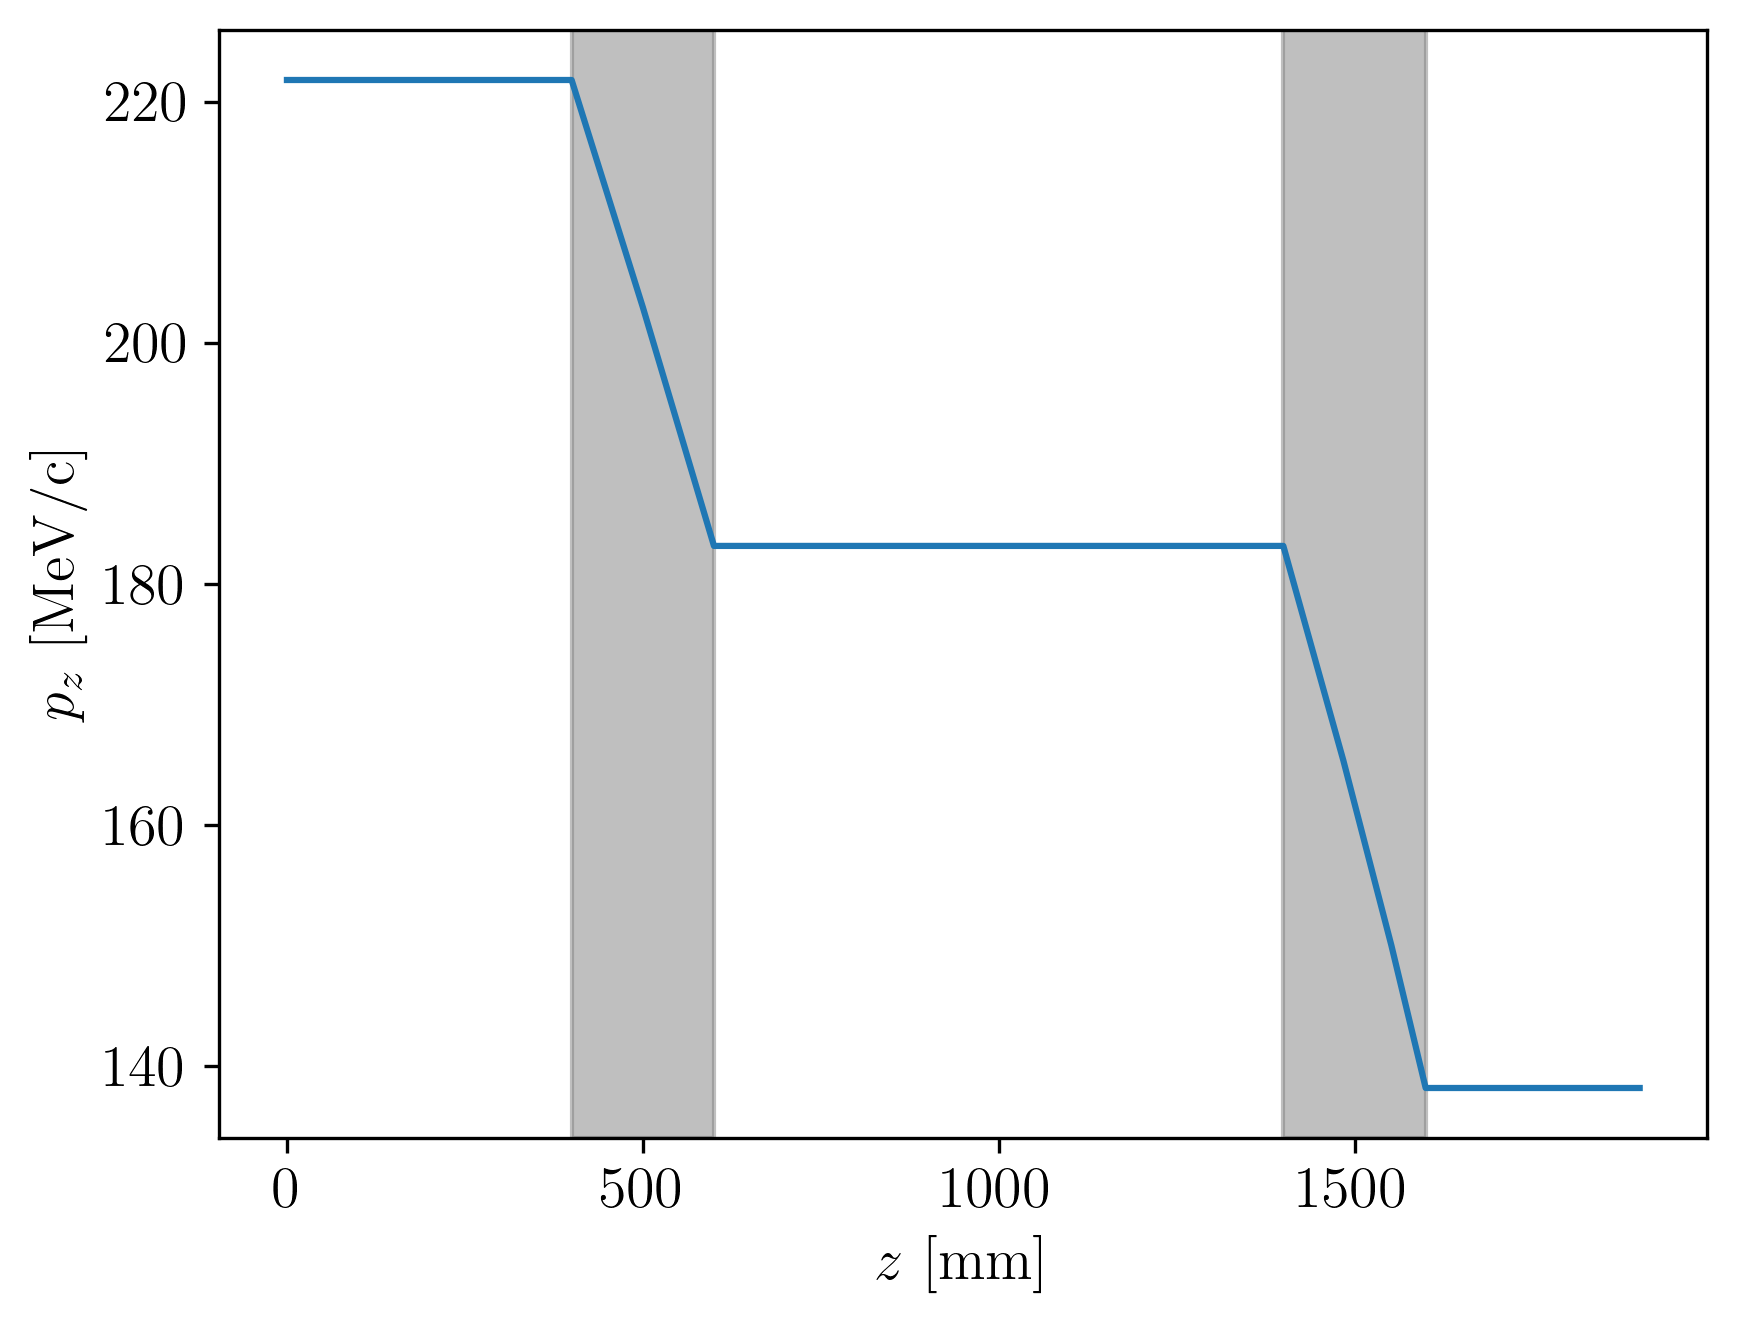

In [26]:
plt.plot(data_vac['z'], data_vac['pz'])
plt.axvspan(400,600,color='gray',alpha=0.5,zorder=-1)
plt.axvspan(1400,1600,color='gray',alpha=0.5,zorder=-1)
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{z}$ [MeV/c]');

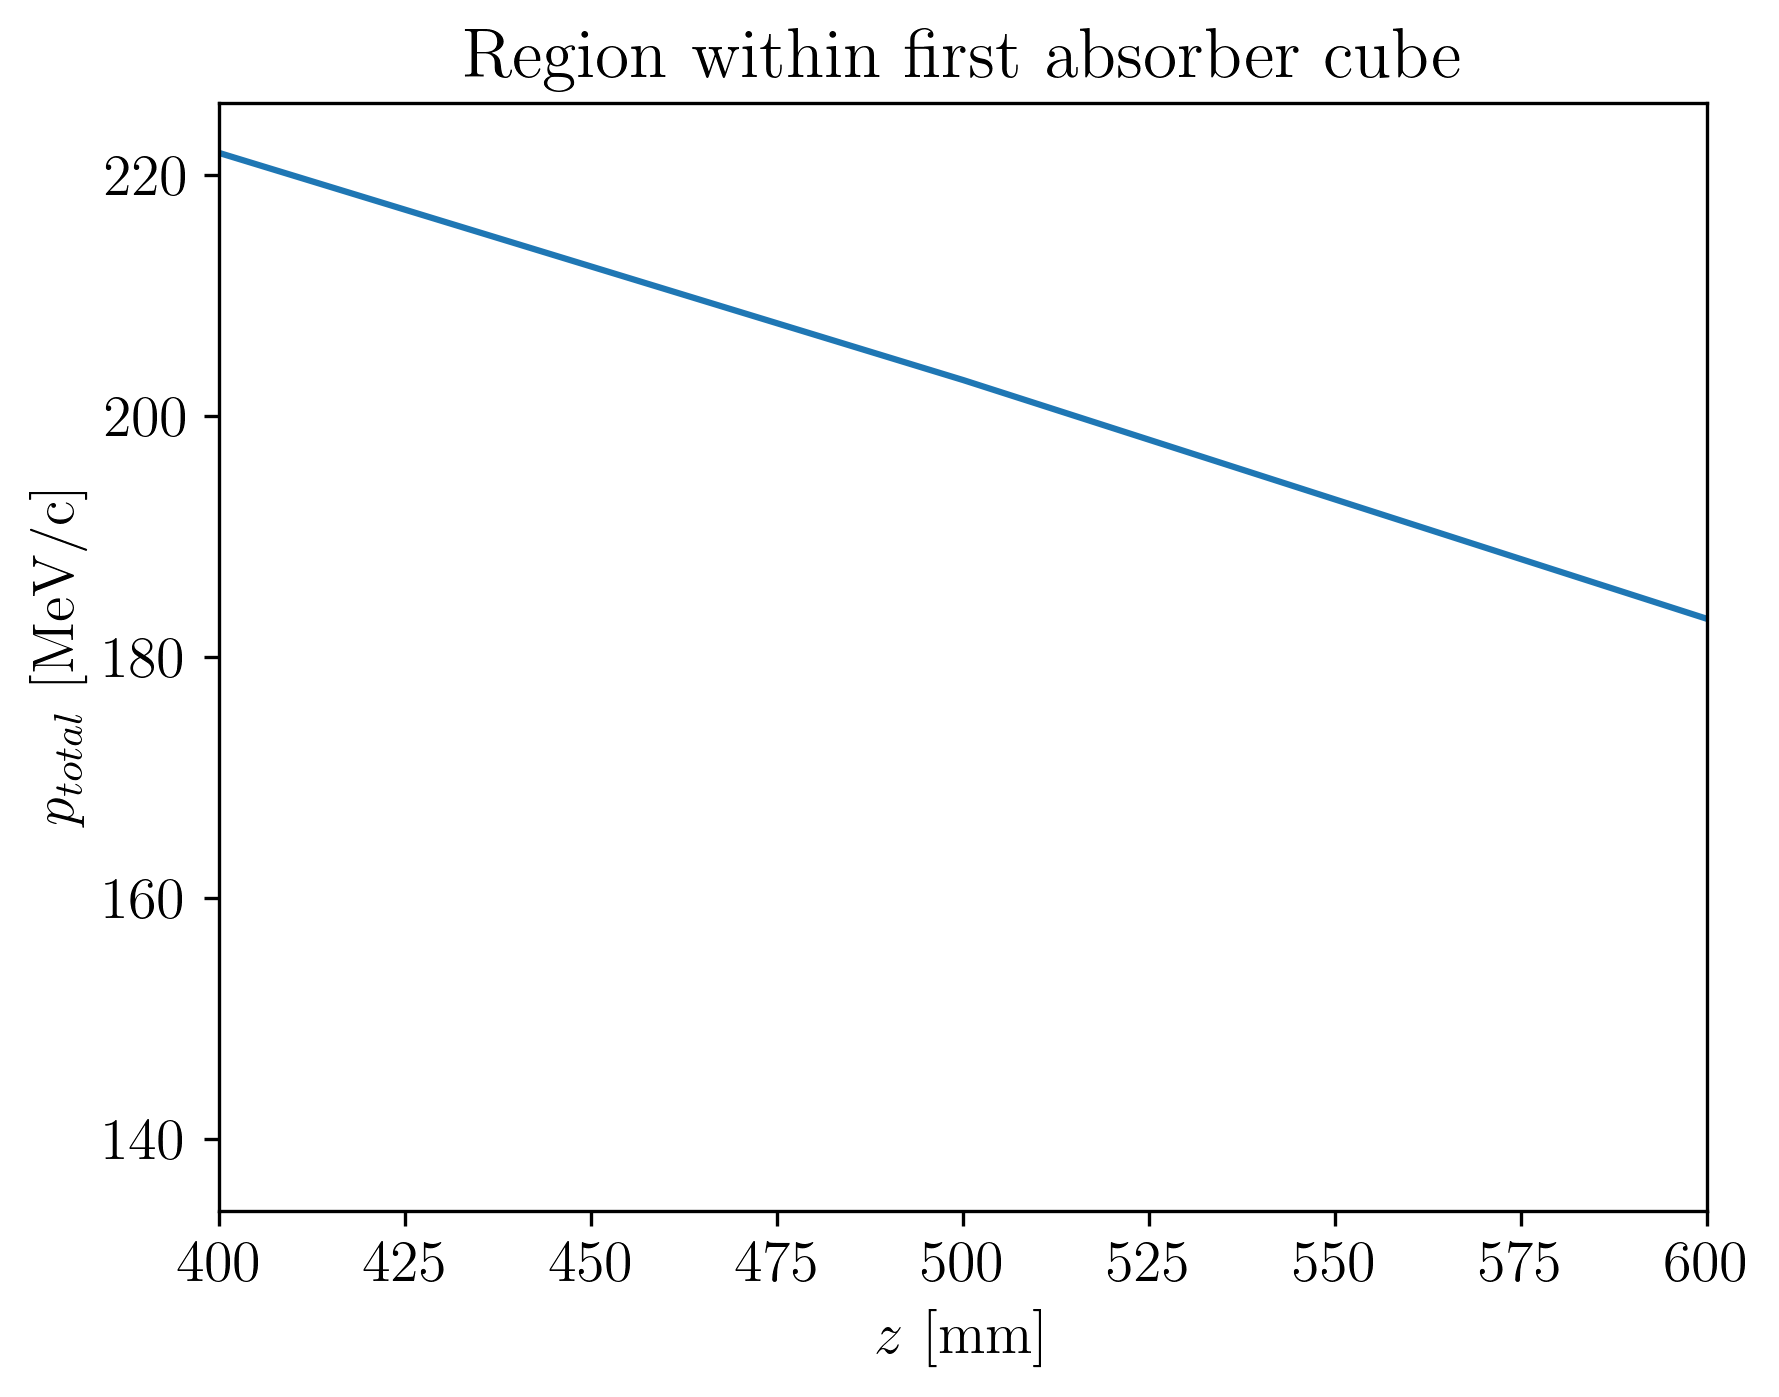

In [27]:
plt.plot(data_vac['z'], data_vac['ptotal'])
plt.xlim((400,600))
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]')
plt.title('Region within first absorber cube');

In [41]:
test_p = data_vac['ptotal'][data_vac['z'] >= 400][data_vac['z'] <= 600]
test_z = data_vac['z'][data_vac['z'] >= 400][data_vac['z'] <= 600]

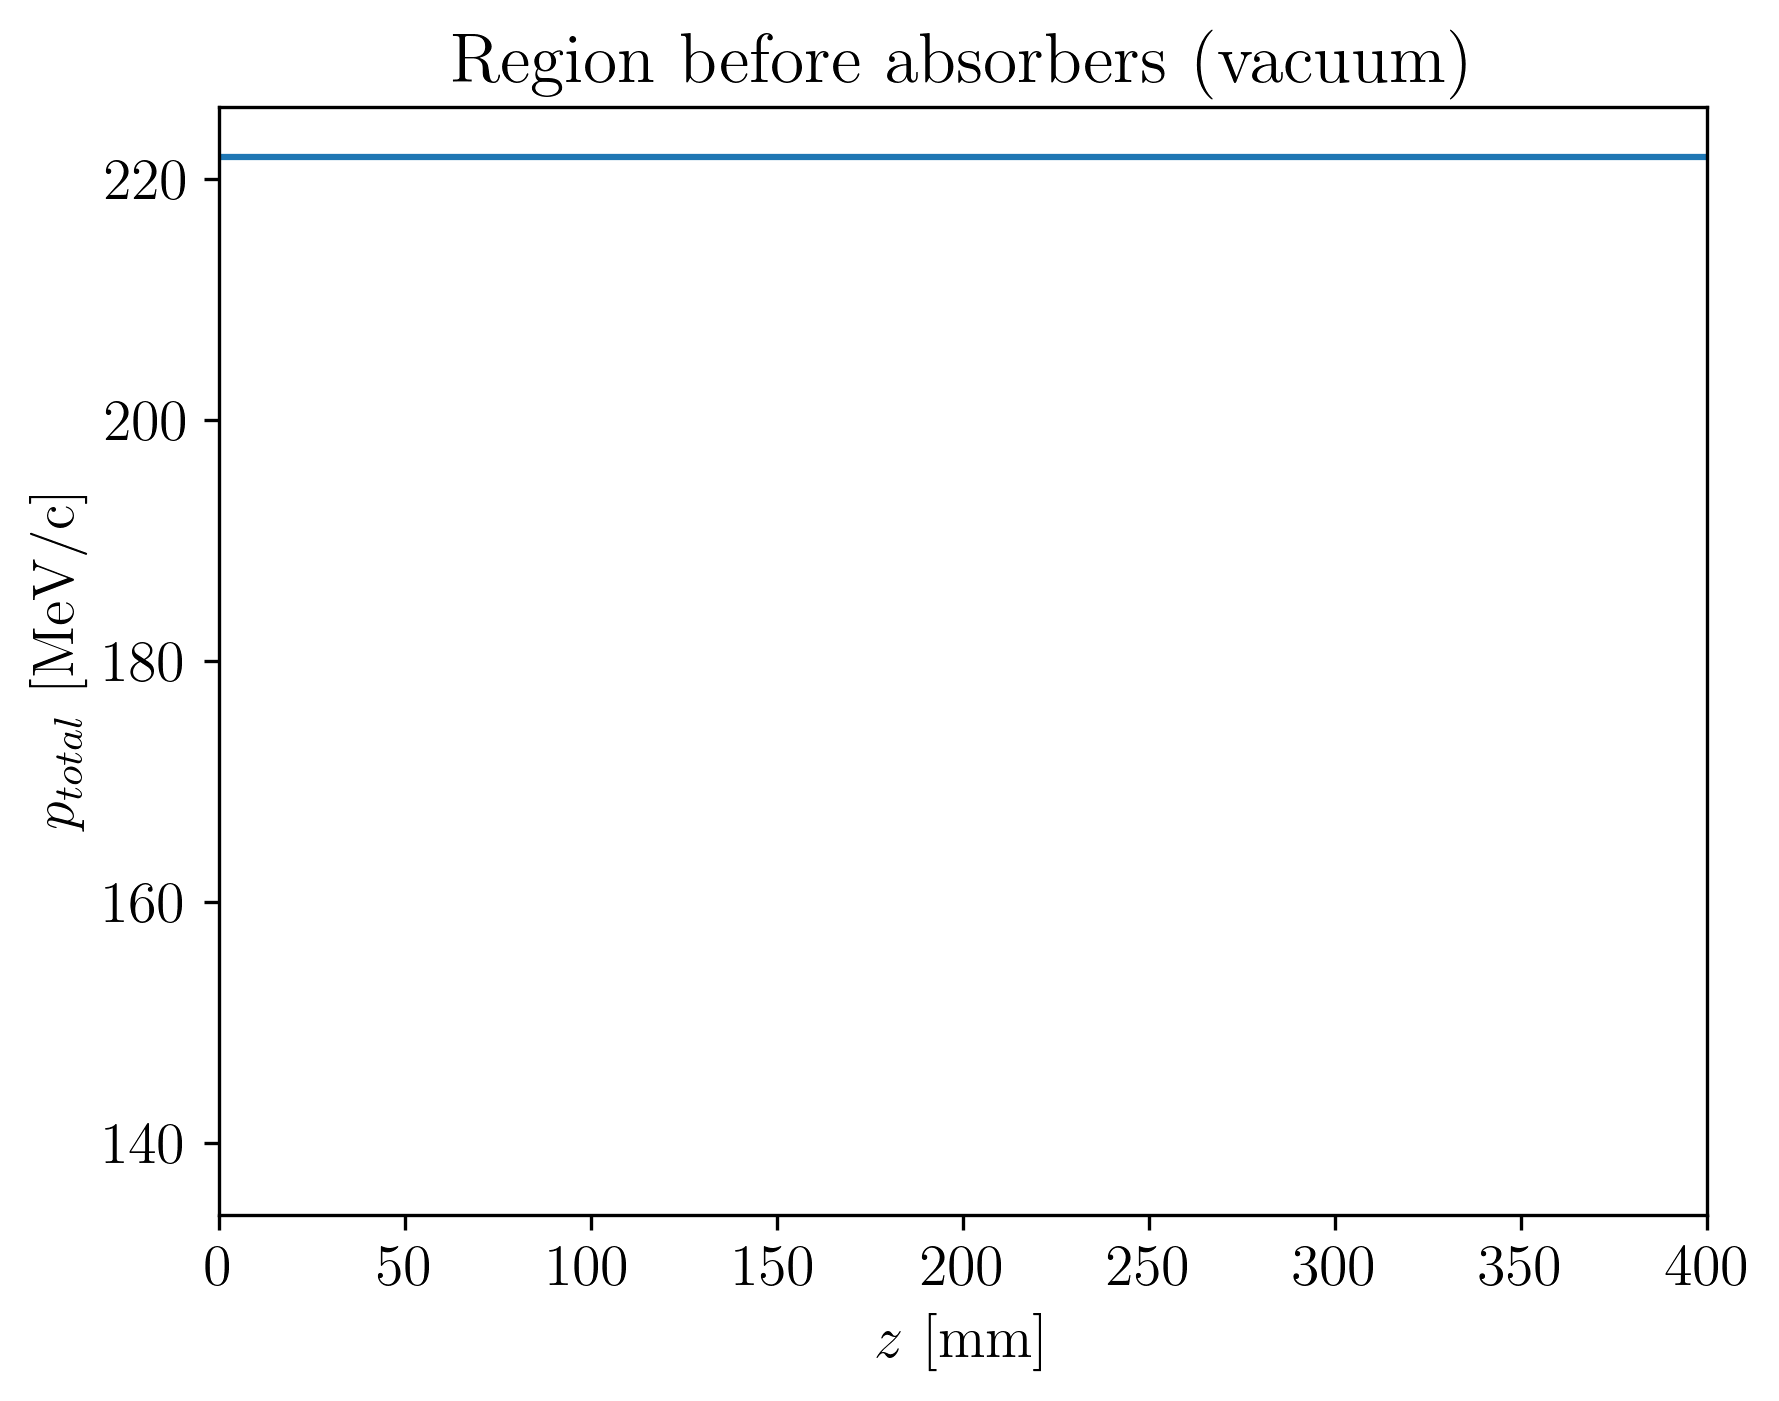

In [42]:
plt.plot(data_vac['z'], data_vac['ptotal'])
plt.xlim((0,400))
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]')
plt.title('Region before absorbers (vacuum)');

### Fit to the ptotal vs z data in the LiH region:

In [47]:
def func(z, a, b):
    return a*z+b

a0 = -0.2
b0 = 300

p0 = [a0, b0]

popt, pcov = curve_fit(func, test_z, test_p, p0=p0)

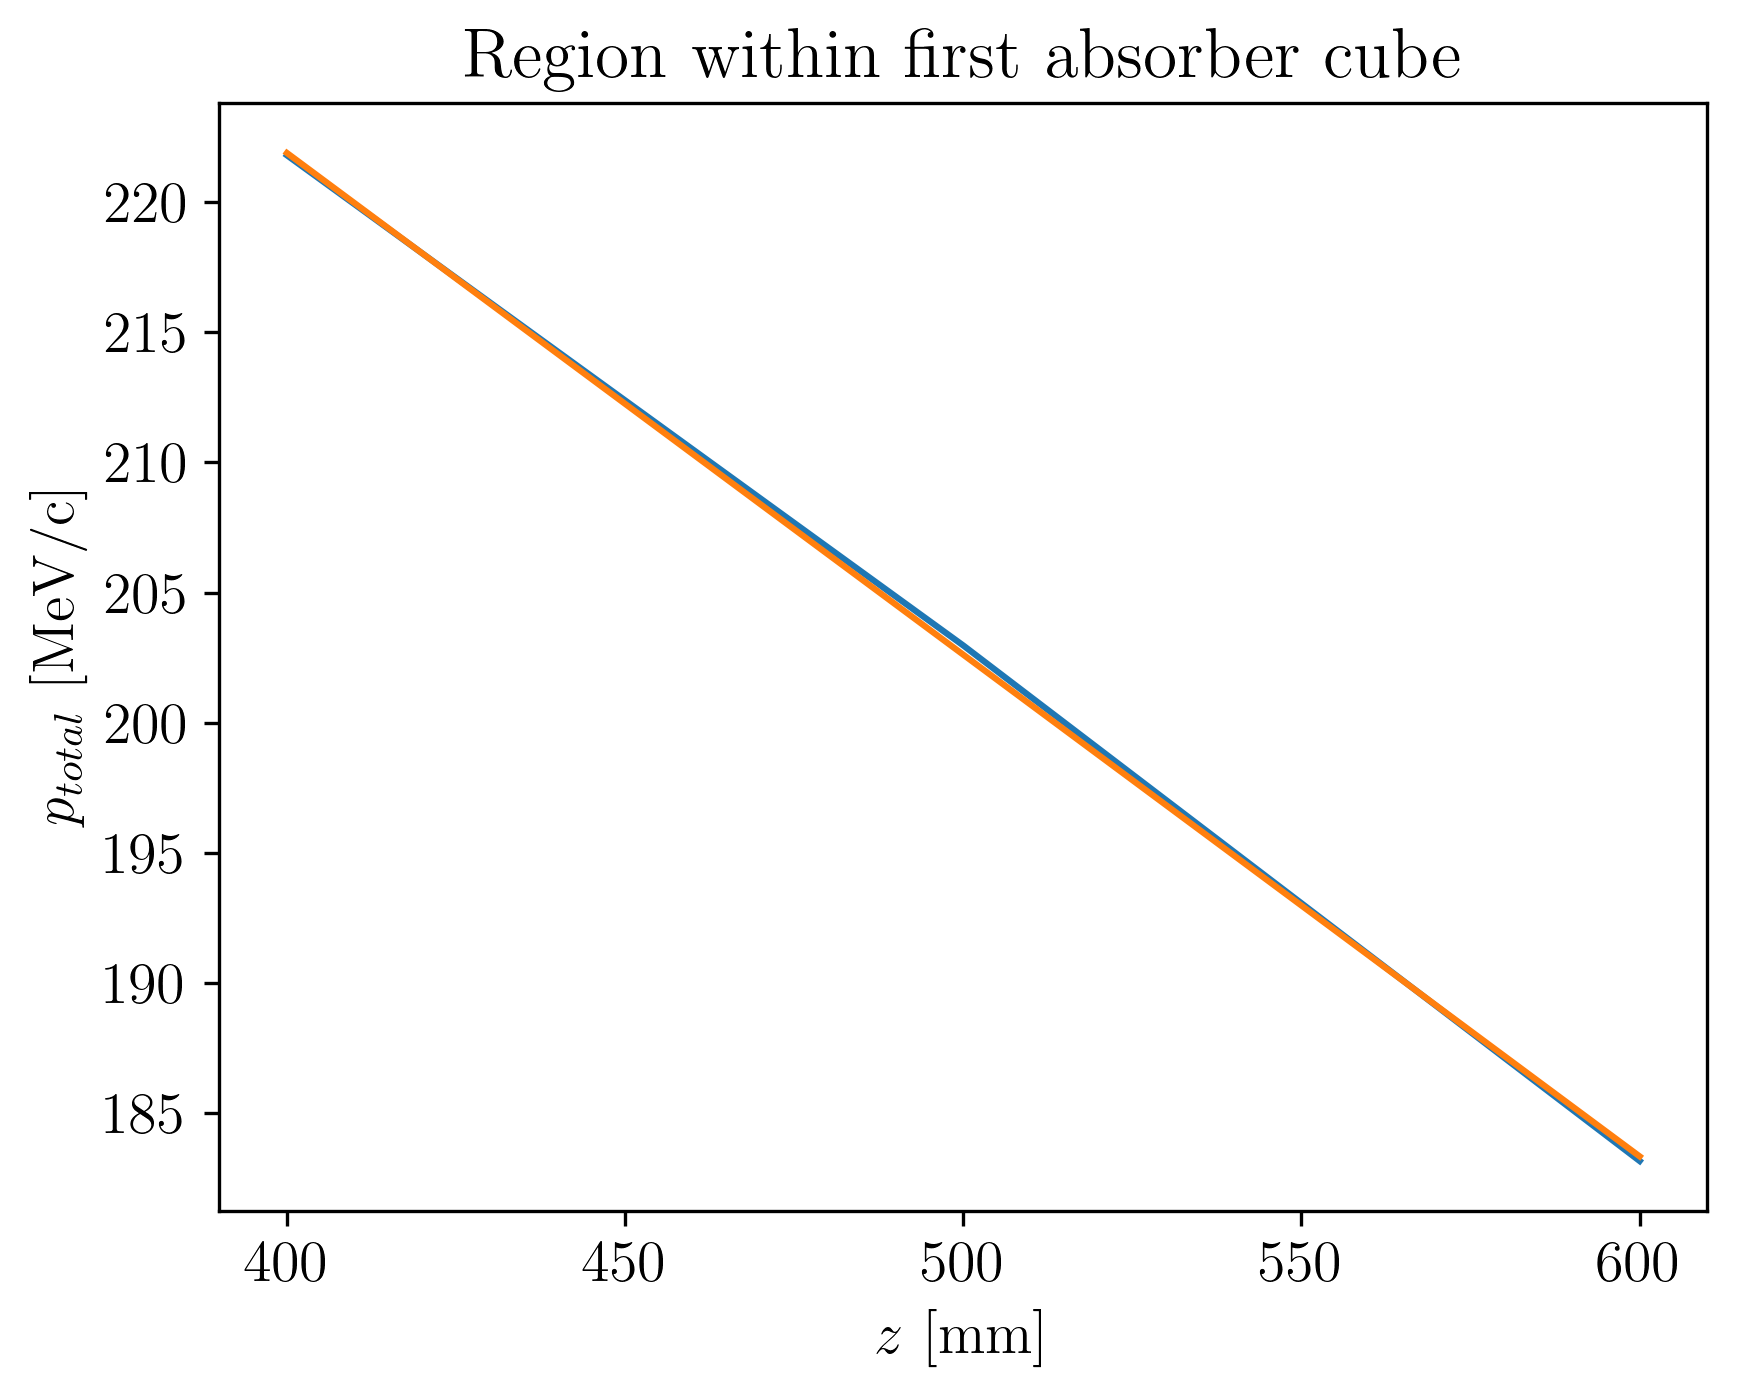

In [48]:
plt.plot(test_z, test_p)
plt.plot(test_z, func(test_z, *popt))
plt.xlabel('$z$ [mm]')
plt.ylabel('$p_{total}$ [MeV/c]')
plt.title('Region within first absorber cube');

In [49]:
print(popt)

[-1.92743636e-01  2.98985727e+02]


In [51]:
print(popt[0]*10)

-1.9274363636362055


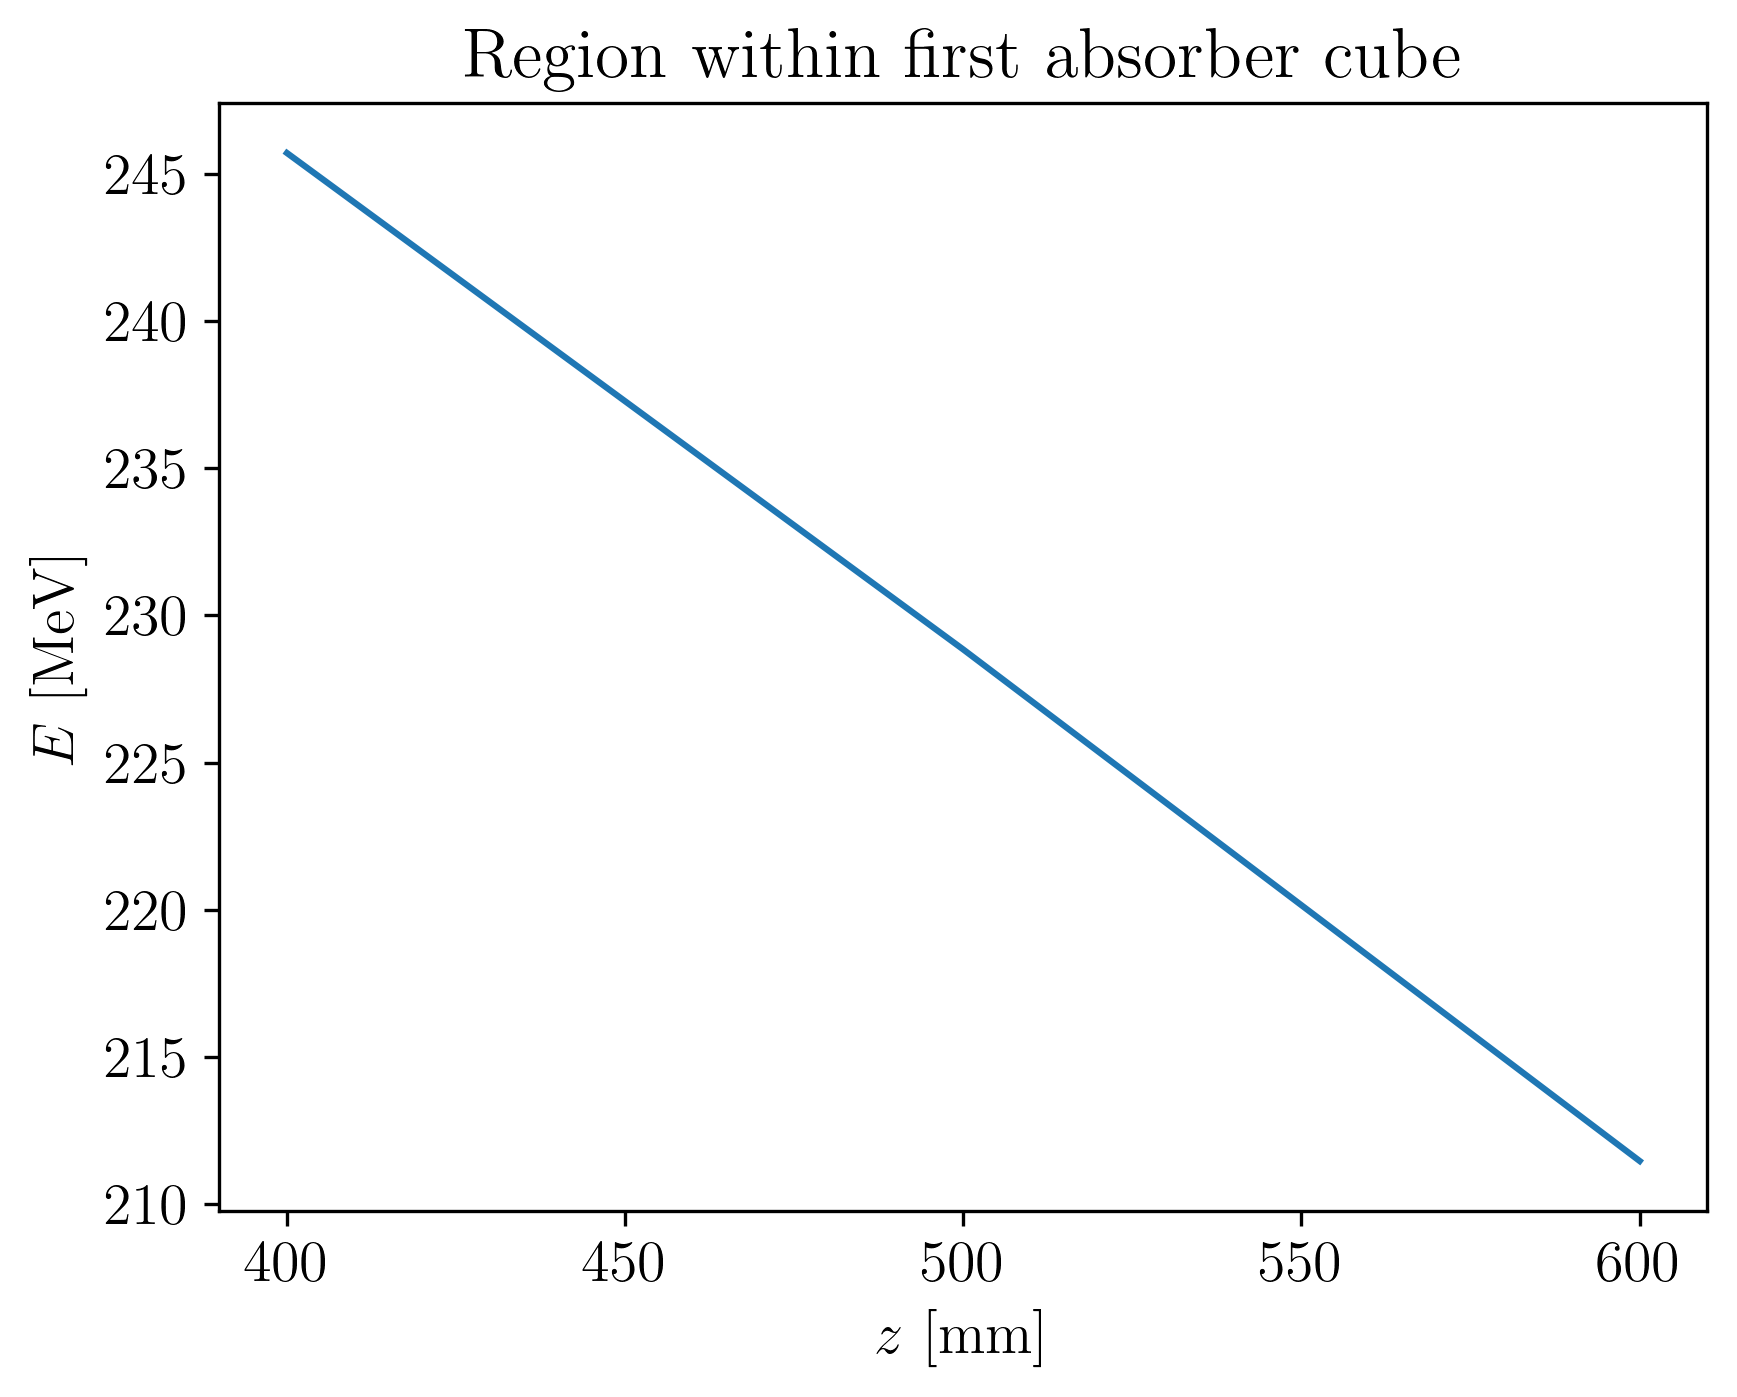

In [58]:
test_E = np.sqrt(test_p**2+105.7**2)
plt.plot(test_z, test_E)
plt.xlabel('$z$ [mm]')
plt.ylabel('$E$ [MeV]')
plt.title('Region within first absorber cube');

In [59]:
popt, pcov = curve_fit(func, test_z, test_E, p0=p0)

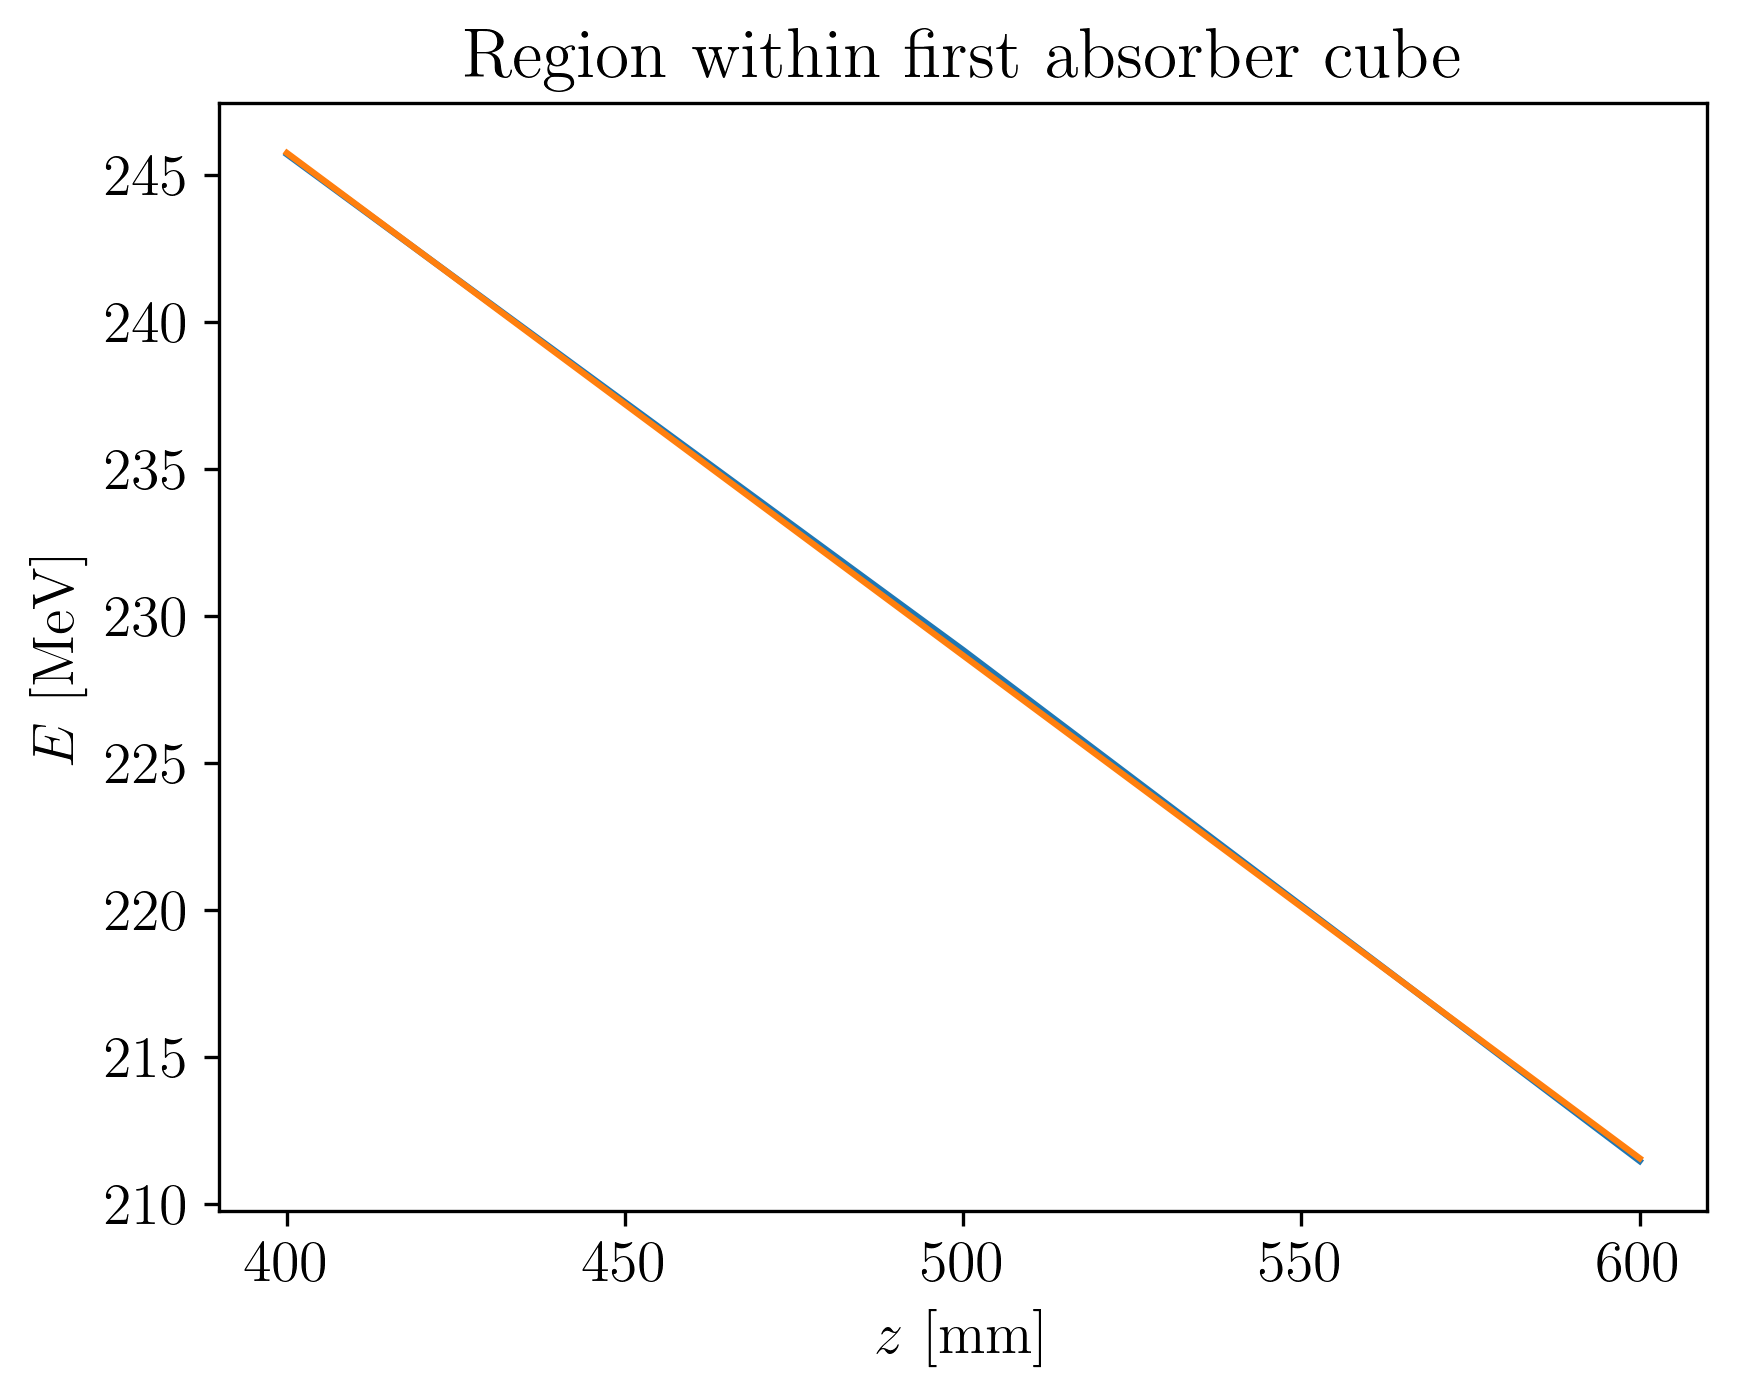

In [60]:
plt.plot(test_z, test_E)
plt.plot(test_z, func(test_z, *popt))
plt.xlabel('$z$ [mm]')
plt.ylabel('$E$ [MeV]')
plt.title('Region within first absorber cube');

In [62]:
popt[0]*10

np.float64(-1.7089171317011655)